# Homework 2: Training Your First Model

The problem we will solve is to convert from Celsius to Fahrenheit, where the approximate formula is:

$$ f = c \times 1.8 + 32 $$

We will not create a conventional Python function that directly performs this calculation. Instead, we will give TensorFlow some sample Celsius value (0, 8, 15, 22, 38) and their corresponding Fahrenheit values (32, 46, 59, 72, 100). Then, we will train a model that figures out the above formula through the training process.

## Import dependencies

First, import TensorFlow.Here, we're calling it `tf` for ease of use. We also tell it to only display errors.

Next, import [NumPy](http://www.numpy.org/) as `np`. Numpy helps us to represent our data as highly performant lists.

In [ ]:
import tensorflow as tf

In [ ]:
import numpy as np
import logging
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

## Set up training data

The task is to create a model that can give the temperature in Fahrenheit when given the degrees in Celsius. We create two lists `celsius_q` and `fahrenheit_a` that we can use to train our model.

In [ ]:
celsius_q = np.array([-40, -10, 0, 8, 15, 22, 38], dtype=float)
fahrenheit_a = np.array([-40, 14, 32, 46, 59, 72, 100], dtype=float)

for i,c in enumerate(celsius_q):
  print("{} degrees Celsius = {} degrees Fahrenheit".format(c, fahrenheit_a[i]))

-40.0 degrees Celsius = -40.0 degrees Fahrenheit
-10.0 degrees Celsius = 14.0 degrees Fahrenheit
0.0 degrees Celsius = 32.0 degrees Fahrenheit
8.0 degrees Celsius = 46.0 degrees Fahrenheit
15.0 degrees Celsius = 59.0 degrees Fahrenheit
22.0 degrees Celsius = 72.0 degrees Fahrenheit
38.0 degrees Celsius = 100.0 degrees Fahrenheit


## Create the model

Next, create the model. We will use the simplest possible model we can, a Dense network. Since the problem is straightforward, this network will require only a single layer, with a single neuron.

### Build a layer

We'll call the layer `l_0` and create it by instantiating `tf.keras.layers.Dense` with the following configuration:

*   `input_shape=[1]` — This specifies that the input to this layer is a single value. That is, the shape is a one-dimensional array with one member. Since this is the first (and only) layer, that input shape is the input shape of the entire model. The single value is a floating point number, representing degrees Celsius.

*   `units=1` — This specifies the number of neurons in the layer. The number of neurons defines how many internal variables the layer has to try to learn how to solve the problem (more later). Since this is the final layer, it is also the size of the model's output — a single float value representing degrees Fahrenheit. (In a multi-layered network, the size and shape of the layer would need to match the `input_shape` of the next layer.)

In [ ]:
# Here I set the learning rate to '0.01'
learning_rate = 0.01
# Here I build the layr l_0
l_0 = tf.keras.layers.Dense(units=64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01), input_shape=[1])  # L2 Regularization added


### Assemble layers into the model

Once layers are defined, they need to be assembled into a model. The Sequential model definition takes a list of layers as an argument, specifying the calculation order from the input to the output.

This model has just a single layer, `l_0`.

In [ ]:
# Next I build the sequential model
model = tf.keras.Sequential([
    l_0,  # First layer, l_0
    tf.keras.layers.Dense(units=1)  # Output layer
])

## Compile the model, with loss and optimizer functions

Before training, the model has to be compiled. When compiled for training, the model is given:

- **Loss function** — A way of measuring how far off predictions are from the desired outcome. (The measured difference is called the "loss".)

- **Optimizer function** — A way of adjusting internal values in order to reduce the loss.

Here, we can use mean squared error as our loss function and `tf.keras.optimizer.Adam` with learning rate as the optimizer.

In [ ]:
# Here I compile the model with using Adam optimizer,learning rate and MSE
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss='mean_squared_error'
)

# Next I checked the model summary for an overview
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                     │ (None, 64)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Note: One part of the Optimizer you may need to think about when building your own models is the learning rate (`0.1` in the code above). This is the step size taken when adjusting values in the model. If the value is too small, it will take too many iterations to train the model. Too large, and accuracy goes down. Finding a good value often involves some trial and error, but the range is usually within 0.001 (default), and 0.1

## Train the model

Train the model by calling the `fit` method.

During training, the model takes in Celsius values, performs a calculation using the current internal variables (called "weights") and outputs values which are meant to be the Fahrenheit equivalent. Since the weights are initially set randomly, the output will not be close to the correct value. The difference between the actual output and the desired output is calculated using the loss function, and the optimizer function directs how the weights should be adjusted.

This cycle of calculate, compare, adjust is controlled by the `fit` method. The first argument is the inputs, the second argument is the desired outputs. The `epochs = 500` argument specifies how many times this cycle should be run, and the `verbose` argument controls how much output the method produces.

In [ ]:
# Here I train the model using the fit method assining output to 'history'
history = model.fit(
    celsius_q,
    fahrenheit_a,
    epochs=500,
    verbose=0
)


## Display training statistics

The `fit` method returns a history object. We can use this object to plot how the loss of our model goes down after each training epoch. A high loss means that the Fahrenheit degrees the model predicts is far from the corresponding value in `fahrenheit_a`.

We'll use [Matplotlib](https://matplotlib.org/) to visualize this (you could use another tool). You will see the model improves very quickly at first, and then has a steady, slow improvement until it is very near "perfect" towards the end.

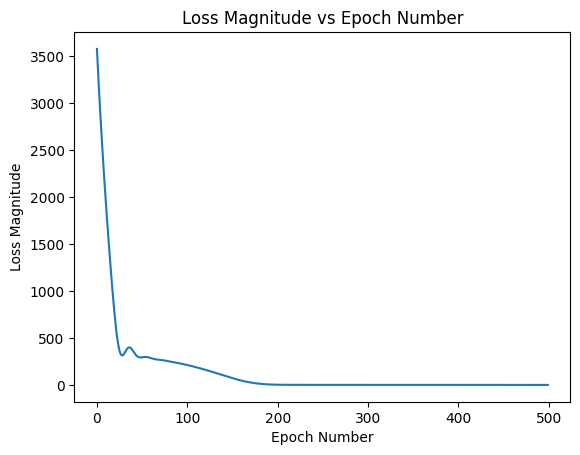

In [ ]:
# Here I import the necessary visualization library
import matplotlib.pyplot as plt

# Next, I Plot Epoch Number (x-axis) and Loss Magnitude (y-axis)
plt.xlabel('Epoch Number')
plt.ylabel('Loss Magnitude')
plt.plot(history.history['loss'])
plt.title('Loss Magnitude vs Epoch Number')
plt.show()


## Use the model to predict values

Now you have a model that has been trained to learn the relationship between `celsius_q` and `fahrenheit_a`. You can use the predict method to have it calculate the Fahrenheit degrees for a previously unknown Celsius degrees.

So, for example, if the Celsius value is 100, what do you think the Fahrenheit result will be? Take a guess before you run this code.

In [ ]:
# Here I use the trained model to predict (if Celsius value is 100)
celsius_value = np.array([100], dtype=float)

# Next I trained model to predict the Fahrenheit value for 100°C
fahrenheit_prediction = model.predict(celsius_value)

# Predication Output
print(f"Predicted Fahrenheit value for {celsius_value[0]}°C: {fahrenheit_prediction[0][0]}°F")




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted Fahrenheit value for 100.0°C: 229.7644805908203°F


## Looking at the layer weights

Finally, let's print the internal variables of the Dense layer.

Check the printed first and second variable. Are they close  to 1.8 and 32 (actual variables in the real conversion formula)?

In [ ]:
# Here I print the internal variables of the Dense layer
print(l_0.get_weights())

[array([[ 0.17935845,  0.03637236, -0.08203972, -0.2892337 , -0.21095288,
         0.33452275,  0.16912179, -0.08315046, -0.21379295, -0.23164056,
        -0.38516727, -0.02422064,  0.18122296,  0.23801917,  0.12084388,
         0.0011663 ,  0.10165489,  0.48009834, -0.07053489, -0.34231758,
        -0.0762812 ,  0.02253079,  0.12545007, -0.35987595, -0.01446234,
         0.5690981 ,  0.06078394,  0.53362006, -0.01361197, -0.06654546,
         0.21656461,  0.42310506,  0.29654616, -0.20647736,  0.34246644,
        -0.275201  ,  0.27330685,  0.46480128,  0.1053536 ,  0.34590036,
         0.21921532, -0.08093107,  0.51361823, -0.27230254, -0.00209962,
         0.13906412, -0.27109832,  0.37698197,  0.5286022 ,  0.00139404,
        -0.2408373 ,  0.06264745,  0.21534444,  0.07318353,  0.25709227,
        -0.32343376, -0.01929499, -0.04545174, -0.14984319, -0.08511262,
        -0.08341343, -0.22336805,  0.01622347,  0.45729855]],
      dtype=float32), array([ 1.2108254 , -0.20351076,  2.671

### A little experiment

What if we created more Dense layers with different units, which therefore also has more variables?

layer `l_0`: `input_shape=[1]` and `units=4`

layer `l_1`: `units=4`

layer `l_2`: `units=1`

After adding these layers, build, compile and train the model with the same parameters as above.

Please also use the trained model to predict if Celsius value is 100, what is the Fahrenheit result will be? Show your result.

Please print weights for layer l_0, l_1 and l_2 with the following format

In [ ]:
# please add layer l_0, l_1 and l_2
l_0 = tf.keras.layers.Dense(units=4, input_shape=[1])
l_1 = tf.keras.layers.Dense(units=4)
l_2 = tf.keras.layers.Dense(units=1)

# please build the model with same parameters as above
model = tf.keras.Sequential([l_0, l_1, l_2])

# please compile the model with the same loss and optimizer function as above
learning_rate = 0.01

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss='mean_squared_error'
)

# please train the model with the same parameters as above
history = model.fit(
    celsius_q,
    fahrenheit_a,
    epochs=500,
    verbose=0
)

# please predict if Ceisius value is 100, what is the Fahrenheit result?
celsius_value = np.array([100], dtype=float)
fahrenheit_prediction = model.predict(celsius_value)
print(f"Predicted Fahrenheit value for {celsius_value[0]}°C: {fahrenheit_prediction[0][0]}°F")

# please print weights for layer `l_0`, `l_1` and `l_2` with the following format
print("These are the l_0 variables: {}".format(l_0.get_weights()))
print("These are the l_1 variables: {}".format(l_1.get_weights()))
print("These are the l_2 variables: {}".format(l_2.get_weights()))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted Fahrenheit value for 100.0°C: 211.7474365234375°F
These are the l_0 variables: [array([[-0.40197667, -0.17913242, -0.03672272,  0.21368942]],
      dtype=float32), array([-1.5501524, -1.8210062, -1.9111841,  1.8769056], dtype=float32)]
These are the l_1 variables: [array([[ 0.6543839 , -0.5328277 , -0.2981775 ,  0.5610164 ],
       [ 0.4804537 , -1.1044352 , -0.23915341, -0.85590816],
       [ 1.4846724 , -1.0213064 , -1.5880033 , -0.75145185],
       [-0.78409255,  0.9700555 ,  0.573995  , -0.3290247 ]],
      dtype=float32), array([-1.5776695,  1.5598638,  1.6135395,  1.3582255], dtype=float32)]
These are the l_2 variables: [array([[-1.0674251],
       [ 1.1171309],
       [ 1.609539 ],
       [ 0.8585765]], dtype=float32), array([1.4041649], dtype=float32)]


# Final Notes on this assignment
* There was as significant improvement in the models perfromance relative to the weights and baises more closely aligning to 1.8 and 32 which suggest to me that the model is learning.
* Also as evident by the improvement in the predicted Fahrenheit value(i.e., 211.7474365234375°F from 229.7644805908203°F the model is improving.
* Perhaps increasing the number of epochs and adjusting the learning rate could improve the model even further.
* Another factor I intend to experiment with outside the scope of this assignment is experimententing with the optimizer.

# Below is my code for HW question 2 parts (C), (D), (E) and (F).

Approximated root: 2.34034732
Number of iterations: 17
Intermediate results: [81, 60.75001411257317, 45.562544036431866, 34.171987320783586, 25.629178444146696, 19.222329342855616, 14.41780295681876, 10.815854659529375, 8.11781859254386, 6.102383790222225, 4.609791548698299, 3.5339063898665897, 2.820369998132399, 2.449582600736096, 2.347439281811251, 2.3403793934458386, 2.340347319980058, 2.340347319320716]


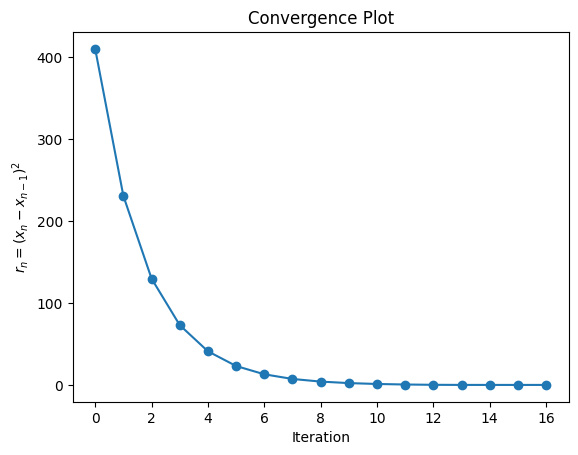


With x0 = 200, τ = 10^-9:
Approximated root: 2.34034732
Number of iterations: 21
Intermediate results: [200, 150.0000009375, 112.50000292534719, 84.37500746149969, 63.281268082023, 47.46098065770293, 35.59580564706758, 26.697020524783582, 20.023159553885368, 15.018303916129861, 11.265942044059306, 8.454701692858219, 6.353436115765014, 4.794320984869401, 3.663798857670656, 2.900347932153706, 2.482665974906067, 2.3521239522861466, 2.3404354694819176, 2.3403473243007222, 2.340347319320716, 2.340347319320716]


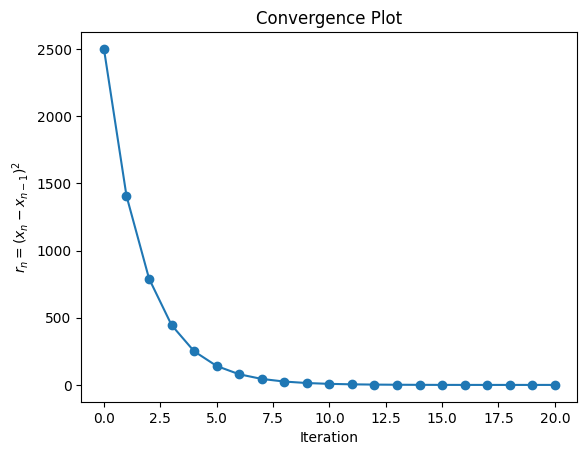

In [ ]:
# (c) Write a Python function that finds the solution to this problem with a tolerance τ = 10^-8, where τ = |xn − xn−1|.

def newtons_method_sqrt4_30(initial_guess=2.0, tolerance=1e-8, max_iterations=1000):
    def f(x):
        return x**4 - 30

    def f_prime(x):
        return 4 * x**3

    x_n = initial_guess
    results = [x_n]

    for iteration in range(max_iterations):
        x_next = x_n - f(x_n) / f_prime(x_n)
        results.append(x_next)
        if abs(x_next - x_n) < tolerance:
            return x_next, iteration + 1, results
            return x_next, iteration + 1, results
        x_n = x_next

    raise ValueError(f"Did not converge within {max_iterations} iterations")

# (d) Set your initial condition x0 = 81. How many iterations are needed? Write down all the intermediate results.

root, iterations, results = newtons_method_sqrt4_30(initial_guess=81)

print(f"Approximated root: {root:.8f}")
print(f"Number of iterations: {iterations}")
print("Intermediate results:", results)

# (e) Let rn = (xn − xn−1)^2, plot rn in Python and save it in eps format.

import matplotlib.pyplot as plt

def plot_rn(results, filename='plot.eps'):
    rn = [(results[i] - results[i-1])**2 for i in range(1, len(results))]

    plt.figure()
    plt.plot(rn, marker='o')
    plt.xlabel('Iteration')
    plt.ylabel(r'$r_n = (x_n - x_{n-1})^2$')
    plt.title('Convergence Plot')
    plt.savefig(filename, format='eps')
    plt.show()

plot_rn(results)

# (f) Change the initial condition to x0 = 200, τ = 10^-9 and repeat steps (d)-(e).

root, iterations, results = newtons_method_sqrt4_30(initial_guess=200, tolerance=1e-9)

print(f"\nWith x0 = 200, τ = 10^-9:")
print(f"Approximated root: {root:.8f}")
print(f"Number of iterations: {iterations}")
print("Intermediate results:", results)

plot_rn(results, filename='plot_x0_200.eps')
